In [ ]:
!hpc-ticket
!hpc-mount wissdaten

# Synthetic dataset Creation

In [13]:
from pathlib import Path
from src.utils import get_data_env

data_path = Path(get_data_env())

def get_disease_path() -> Path:
    """Path to disease CSV file."""
    return data_path / 'processed/germany/epidemiology/casedata/survstat' / f'measles.csv'

def get_population_path() -> Path:
    """Path to population CSV file."""
    return data_path / 'processed/germany/sociodemography/population_size_03.csv'

def get_population_berlin_districts_path() -> Path:
    """Path to berlin - districts population (2024) CSV file."""
    return data_path / 'processed/germany/sociodemography/population_size_berlin_districts_03.csv'    

def get_nuts_shapefile_path() -> Path:
    """Path to shapefile."""
    return data_path / f'processed/germany/geospatial/shapefiles/shape_nuts3.shp'

def get_nuts_harmonization_path() -> Path:
    """Path to NUTS names file."""
    return data_path / 'processed/germany/geospatial/harmonization/nuts.tsv'

In [14]:
import pandas as pd 
import geopandas as gpd

mv = pd.read_csv(get_disease_path(), parse_dates= ['timestamp'], dtype = {'kz_kreis': str})
shp= gpd.read_file(get_nuts_shapefile_path())

shp = shp[shp['nuts3_key'] != '11000'].reset_index(drop = True)

In [90]:
import pandas as pd
import numpy as np
from scipy.sparse.csgraph import shortest_path
from typing import List, Optional, Tuple
import torch
import seaborn as sns 
import matplotlib.pyplot as plt 
from matplotlib.figure import Figure


class SyntheticDataSimulator:
    """
    Base class for generating synthetic spatiotemporal epidemic data.
    
    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        GeoDataFrame containing geographic units (Kreise)
    graph_structure : GraphStructure
        Graph structure with edge_index and edge_weight
    nuts_column : str
        Column name in gdf containing NUTS identifiers (default: 'nuts3_key')
    """
    
    def __init__(self, gdf, graph_structure, nuts_column='nuts3_key'):
        self.gdf = gdf
        self.graph_structure = graph_structure
        self.N = len(gdf)
        self.nuts_column = nuts_column
        
        # Convert graph structure to adjacency matrix for computations
        self.adjacency = self._graph_to_adjacency()
        
        # Compute spatial coordinates (normalized)
        self.coords = np.column_stack([
            gdf.geometry.centroid.x,
            gdf.geometry.centroid.y
        ])
        self.coords = (self.coords - self.coords.mean(axis=0)) / self.coords.std(axis=0)
    
    def _graph_to_adjacency(self):
        """Convert GraphStructure (edge_index, edge_weight) to dense adjacency matrix"""
        adjacency = np.zeros((self.N, self.N))
        
        edge_index = self.graph_structure.edge_index.cpu().numpy()
        edge_weight = self.graph_structure.edge_weight.cpu().numpy()
        
        for i in range(edge_index.shape[1]):
            src = edge_index[0, i]
            dst = edge_index[1, i]
            weight = edge_weight[i]
            adjacency[src, dst] = weight
        
        return adjacency
    
    def simulate_multi_year(self, years_train: List[int], years_val: List[int], 
                           years_test: List[int], pre_weeks: int = 10, 
                           post_weeks: int = 10, **kwargs):
        """
        Simulate disease data across multiple years.
        Must be implemented by child classes.
        """
        raise NotImplementedError("Child classes must implement simulate_multi_year")
    
    def _to_dataframe(self, cases: np.ndarray, timestamps: pd.DatetimeIndex, 
                     pre_weeks: int, post_weeks: int) -> pd.DataFrame:
        """Convert cases array to dataframe with proper structure"""
        records = []
        for t, timestamp in enumerate(timestamps):
            for node in range(self.N):
                records.append({
                    'timestamp': timestamp,
                    'cases': int(cases[t, node]),
                    'year': timestamp.year,
                    'week': timestamp.isocalendar()[1],
                    self.nuts_column: self.gdf.iloc[node][self.nuts_column]
                })
        
        df = pd.DataFrame(records)
        
        if pre_weeks > 0 or post_weeks > 0:
            df = self._add_padding(df, pre_weeks, post_weeks)
        
        return df
    
    def _add_padding(self, df: pd.DataFrame, weeks_pre: int, 
                    weeks_post: int) -> pd.DataFrame:
        """Add zero-padding before and after the main data"""
        if weeks_pre == 0 and weeks_post == 0:
            return df
        
        nuts_list = df[self.nuts_column].unique()
        t_start = df['timestamp'].min()
        t_end = df['timestamp'].max()
        padding_records = []
        
        # Pre-padding
        for w in range(1, weeks_pre + 1):
            pad_date = t_start - pd.Timedelta(weeks=w)
            for nuts in nuts_list:
                padding_records.append({
                    'timestamp': pad_date,
                    'cases': 0,
                    'year': pad_date.year,
                    'week': pad_date.isocalendar()[1],
                    self.nuts_column: nuts
                })
        
        # Post-padding
        for w in range(1, weeks_post + 1):
            pad_date = t_end + pd.Timedelta(weeks=w)
            for nuts in nuts_list:
                padding_records.append({
                    'timestamp': pad_date,
                    'cases': 0,
                    'year': pad_date.year,
                    'week': pad_date.isocalendar()[1],
                    self.nuts_column: nuts
                })
        
        df_padded = pd.concat([pd.DataFrame(padding_records), df], ignore_index=True)
        df_padded = df_padded.sort_values([self.nuts_column, 'timestamp']).reset_index(drop=True)
        return df_padded
    
    def _get_date_range(self, years_train: List[int], years_val: List[int], 
                       years_test: List[int]):
        """Helper to get start and end dates from year lists"""
        all_years = sorted(set(years_train + years_val + years_test))
        start_date = pd.Timestamp(year=min(all_years), month=1, day=1)
        end_date = pd.Timestamp(year=max(all_years), month=12, day=31)
        return start_date, end_date

    def preview(self, weeks: int = 52, nodes_to_plot: Optional[List[int]] = None,
                figsize: Tuple[int, int] = (15, 10), **kwargs) -> Figure:
        """
        Generate a preview of the simulated data.
        
        Parameters
        ----------
        weeks : int
            Number of weeks to simulate for preview (default: 52)
        nodes_to_plot : Optional[List[int]]
            Specific node indices to highlight. If None, random selection.
        figsize : Tuple[int, int]
            Figure size (default: (15, 10))
        **kwargs
            Additional parameters passed to simulate_multi_year
        
        Returns
        -------
        plt.Figure
            Matplotlib figure with preview plots
        """
        # Generate preview data
        preview_year = 2020
        df_preview = self.simulate_multi_year(
            years_train=[preview_year],
            years_val=[],
            years_test=[],
            pre_weeks=0,
            post_weeks=0,
            **kwargs
        )
        
        # Limit to requested weeks
        df_preview = df_preview.head(weeks * self.N)
        
        # Pivot for easier plotting
        df_pivot = df_preview.pivot(index='timestamp', 
                                     columns=self.nuts_column, 
                                     values='cases')
        
        # Select nodes to highlight
        if nodes_to_plot is None:
            nodes_to_plot = np.random.choice(self.N, size=min(5, self.N), replace=False)
        
        # Create figure
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
        
        # 1. Time series of selected nodes
        ax1 = fig.add_subplot(gs[0, :])
        for node_idx in nodes_to_plot:
            nuts_id = self.gdf.iloc[node_idx][self.nuts_column]
            ax1.plot(df_pivot.index, df_pivot[nuts_id], 
                    label=f'Node {node_idx} ({nuts_id})', alpha=0.7, linewidth=2)
        ax1.set_xlabel('Time', fontsize=12)
        ax1.set_ylabel('Cases', fontsize=12)
        ax1.set_title('Time Series: Selected Nodes', fontsize=14, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # 2. Heatmap of all nodes over time
        ax2 = fig.add_subplot(gs[1, :])
        
        # Subsample for visibility if too many weeks
        if len(df_pivot) > 100:
            step = len(df_pivot) // 100
            df_heatmap = df_pivot.iloc[::step, :]
        else:
            df_heatmap = df_pivot
        
        sns.heatmap(df_heatmap.T, cmap='YlOrRd', ax=ax2, 
                   cbar_kws={'label': 'Cases'}, 
                   xticklabels=False, yticklabels=False)
        ax2.set_xlabel('Time', fontsize=12)
        ax2.set_ylabel('Nodes (Kreise)', fontsize=12)
        ax2.set_title('Spatiotemporal Heatmap: All Nodes', fontsize=14, fontweight='bold')
        
        # 3. Geographic snapshot at peak
        ax3 = fig.add_subplot(gs[2, 0])
        total_cases = df_pivot.sum(axis=1)
        peak_time = total_cases.idxmax()
        peak_data = df_pivot.loc[peak_time]
        
        self.gdf['preview_cases'] = self.gdf[self.nuts_column].map(peak_data)
        self.gdf.plot(column='preview_cases', cmap='YlOrRd', 
                     legend=True, ax=ax3, edgecolor='black', linewidth=0.5)
        ax3.set_title(f'Geographic Distribution at Peak\n({peak_time.strftime("%Y-%m-%d")})', 
                     fontsize=12, fontweight='bold')
        ax3.axis('off')
        
        # 4. Statistics and correlation
        ax4 = fig.add_subplot(gs[2, 1])
        ax4.axis('off')
        
        # Calculate statistics
        mean_cases = df_preview['cases'].mean()
        std_cases = df_preview['cases'].std()
        max_cases = df_preview['cases'].max()
        min_cases = df_preview['cases'].min()
        
        # Temporal autocorrelation (for first node as example)
        first_node = df_pivot.iloc[:, 0].dropna()
        if len(first_node) > 1:
            autocorr_1 = first_node.autocorr(lag=1)
        else:
            autocorr_1 = np.nan
        
        # Spatial correlation at peak
        if hasattr(self, 'adjacency'):
            spatial_corr = self._compute_spatial_correlation(peak_data)
        else:
            spatial_corr = np.nan
        
        stats_text = f"""
SIMULATION STATISTICS
{'='*40}

Temporal:
  • Duration: {len(df_pivot)} weeks
  • Total observations: {len(df_preview)}

Case Distribution:
  • Mean: {mean_cases:.1f}
  • Std Dev: {std_cases:.1f}
  • Min: {min_cases:.1f}
  • Max: {max_cases:.1f}

Patterns:
  • Temporal autocorr (lag=1): {autocorr_1:.3f}
  • Spatial correlation: {spatial_corr:.3f}
  
Graph Properties:
  • Nodes: {self.N}
  • Edges: {int(self.adjacency.sum() / 2)}
        """
        
        ax4.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                verticalalignment='center', transform=ax4.transAxes)
        
        # Add simulator info
        sim_name = self.__class__.__name__
        fig.suptitle(f'Preview: {sim_name}', fontsize=16, fontweight='bold', y=0.995)
        
        return fig
    
    def _compute_spatial_correlation(self, cases_series: pd.Series) -> float:
        """
        Compute Moran's I-like spatial correlation.
        High values indicate neighboring nodes have similar case counts.
        """
        try:
            cases_array = cases_series.values
            
            # Compute spatial lag (weighted average of neighbors)
            n = len(cases_array)
            spatial_lag = np.zeros(n)
            
            for i in range(n):
                neighbors = np.where(self.adjacency[i] > 0)[0]
                if len(neighbors) > 0:
                    spatial_lag[i] = cases_array[neighbors].mean()
            
            # Pearson correlation between cases and spatial lag
            if np.std(cases_array) > 0 and np.std(spatial_lag) > 0:
                corr = np.corrcoef(cases_array, spatial_lag)[0, 1]
                return corr
            else:
                return 0.0
        except:
            return np.nan
    
    def compare_graphs(self, identity_graph, neighbor_graph, weeks: int = 52,
                      test_node: Optional[int] = None, figsize: Tuple[int, int] = (15, 8),
                      **kwargs) -> Figure:
        """
        Compare how data looks different through identity vs. neighbor graphs.
        
        Parameters
        ----------
        identity_graph : GraphStructure
            Identity graph (each node only connects to itself)
        neighbor_graph : GraphStructure
            Geographic neighbor graph
        weeks : int
            Number of weeks to simulate
        test_node : Optional[int]
            Node to focus on. If None, picks a central node.
        **kwargs
            Parameters for simulation
        
        Returns
        -------
        plt.Figure
            Comparison visualization
        """
        # Generate data
        preview_year = 2020
        df = self.simulate_multi_year(
            years_train=[preview_year],
            years_val=[],
            years_test=[],
            pre_weeks=0,
            post_weeks=0,
            **kwargs
        )
        
        df = df.head(weeks * self.N)
        df_pivot = df.pivot(index='timestamp', columns=self.nuts_column, values='cases')
        
        # Select test node
        if test_node is None:
            # Pick node with most neighbors
            neighbor_counts = self.adjacency.sum(axis=1)
            test_node = int(np.argmax(neighbor_counts))
        
        test_nuts = self.gdf.iloc[test_node][self.nuts_column]
        
        # Get neighbors
        neighbor_indices = np.where(self.adjacency[test_node] > 0)[0]
        neighbor_indices = neighbor_indices[neighbor_indices != test_node]  # exclude self
        
        # Create figure
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'Identity vs. Neighbor Graph Comparison\nTest Node: {test_node} ({test_nuts})',
                    fontsize=14, fontweight='bold')
        
        # 1. Identity Graph View (only self)
        ax1 = axes[0, 0]
        ax1.plot(df_pivot.index, df_pivot[test_nuts], 
                linewidth=2, color='blue', label='Self')
        ax1.set_title('Identity Graph: Node sees only itself', fontweight='bold')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Cases')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Neighbor Graph View (self + neighbors)
        ax2 = axes[0, 1]
        ax2.plot(df_pivot.index, df_pivot[test_nuts], 
                linewidth=2, color='blue', label='Self', zorder=10)
        
        for i, neighbor_idx in enumerate(neighbor_indices[:5]):  # Show max 5 neighbors
            neighbor_nuts = self.gdf.iloc[neighbor_idx][self.nuts_column]
            ax2.plot(df_pivot.index, df_pivot[neighbor_nuts], 
                    alpha=0.5, linewidth=1.5, label=f'Neighbor {neighbor_idx}')
        
        ax2.set_title(f'Neighbor Graph: Node + {len(neighbor_indices)} neighbors', 
                     fontweight='bold')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Cases')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        # 3. Geographic context
        ax3 = axes[1, 0]
        self.gdf.plot(ax=ax3, color='lightgray', edgecolor='black', linewidth=0.5)
        
        # Highlight test node
        self.gdf.iloc[[test_node]].plot(ax=ax3, color='blue', edgecolor='black', 
                                         linewidth=2, label='Test Node')
        
        # Highlight neighbors
        if len(neighbor_indices) > 0:
            self.gdf.iloc[neighbor_indices].plot(ax=ax3, color='orange', 
                                                 edgecolor='black', linewidth=1,
                                                 alpha=0.6, label='Neighbors')
        
        ax3.set_title('Geographic Context', fontweight='bold')
        ax3.legend()
        ax3.axis('off')
        
        # 4. Predictive information
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Calculate how much neighbors help prediction
        target_series = df_pivot[test_nuts].values
        
        # Simple metric: correlation between neighbor average and next timestep
        if len(neighbor_indices) > 0:
            neighbor_avg = df_pivot.iloc[:, neighbor_indices].mean(axis=1).values
            
            # Lag correlation (does neighbor state predict next timestep?)
            if len(target_series) > 1:
                self_corr = np.corrcoef(target_series[:-1], target_series[1:])[0, 1]
                neighbor_corr = np.corrcoef(neighbor_avg[:-1], target_series[1:])[0, 1]
            else:
                self_corr = np.nan
                neighbor_corr = np.nan
        else:
            neighbor_corr = np.nan
            self_corr = np.nan
        
        info_text = f"""
PREDICTIVE INFORMATION
{'='*40}

Test Node: {test_node}
NUTS ID: {test_nuts}
Neighbors: {len(neighbor_indices)}

Autocorrelation (self history):
  {self_corr:.3f}

Cross-correlation (neighbor → self):
  {neighbor_corr:.3f}

Information Gain:
  {neighbor_corr - self_corr:.3f}
  
{'Graph helps!' if neighbor_corr > self_corr else 'Graph may not help'}
        """
        
        ax4.text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                verticalalignment='center', transform=ax4.transAxes)
        
        plt.tight_layout()
        return fig


class WavePropagationSimulator(SyntheticDataSimulator):
    """
    Simulates epidemic waves spreading from epicenters through the graph.
    Waves propagate based on graph distance with time delays.
    
    This creates strong graph dependency: nodes experience peaks at different
    times based on their distance from the epicenter. An identity graph cannot
    predict when the wave will arrive, but a GCN can see it approaching.
    
    Parameters
    ----------
    num_waves : int
        Number of epidemic waves to generate (default: 3)
    wave_speed : float
        Speed of wave propagation in graph-distance/week (default: 1.5)
    amplitude_base : float
        Base amplitude of epidemic peaks (default: 100)
    amplitude_noise : float
        Standard deviation of amplitude noise (default: 20)
    """
    
    def __init__(self, gdf, graph_structure, nuts_column='nuts3_key'):
        super().__init__(gdf, graph_structure, nuts_column)
        self._compute_graph_distances()
    
    def _compute_graph_distances(self):
        """Compute shortest path distances on graph using BFS"""
        # Use scipy's shortest_path on the adjacency matrix
        # This gives us the minimum number of hops between any two nodes
        self.distances = shortest_path(self.adjacency, directed=False, unweighted=True)
        
        # Replace infinities (disconnected nodes) with large value
        self.distances[np.isinf(self.distances)] = self.N * 2
    
    def simulate_multi_year(self, years_train: List[int], years_val: List[int],
                           years_test: List[int], pre_weeks: int = 10,
                           post_weeks: int = 10, num_waves: int = 3,
                           wave_speed: float = 1.5, amplitude_base: float = 100,
                           amplitude_noise: float = 20) -> pd.DataFrame:
        """
        Simulate multiple epidemic waves starting from random epicenters.
        
        Each wave:
        1. Starts at a random node (epicenter)
        2. Propagates outward based on graph distance
        3. Peaks at each node when wave_time matches graph distance
        4. Uses Gaussian profile for smooth temporal evolution
        """
        
        start_date, end_date = self._get_date_range(years_train, years_val, years_test)
        timestamps = pd.date_range(start=start_date, end=end_date, freq='W-MON')
        num_weeks = len(timestamps)
        
        cases = np.zeros((num_weeks, self.N))
        
        # Generate waves at different times across the simulation period
        wave_starts = np.linspace(5, num_weeks - 20, num_waves, dtype=int)
        
        for wave_idx, wave_start in enumerate(wave_starts):
            # Random epicenter for this wave
            epicenter = np.random.choice(self.N)
            
            # Wave duration (propagates for ~30 weeks)
            wave_duration = min(30, num_weeks - wave_start)
            
            for t in range(wave_start, wave_start + wave_duration):
                # Current "position" of wave front
                wave_time = (t - wave_start) * wave_speed
                
                for node in range(self.N):
                    # Graph distance from epicenter to this node
                    distance = self.distances[epicenter, node]
                    
                    # Wave peaks when wave_time ≈ distance
                    # Gaussian centered at distance with width=2
                    time_alignment = wave_time - distance
                    peak_factor = np.exp(-0.5 * (time_alignment / 2.0) ** 2)
                    
                    # Amplitude with some randomness per node
                    amplitude = amplitude_base + np.random.normal(0, amplitude_noise)
                    
                    cases[t, node] += amplitude * peak_factor
        
        # Add baseline noise
        cases += np.random.poisson(5, size=cases.shape)
        cases = np.clip(cases, 0, None).astype(int)
        
        return self._to_dataframe(cases, timestamps, pre_weeks, post_weeks)


class StandingWaveSimulator(SyntheticDataSimulator):
    """
    Simulates a traveling sinusoidal wave moving across geographic space.
    
    Each node oscillates with the same frequency but different phase based on
    its geographic position (e.g., North-South gradient). An LSTM can learn
    the frequency but cannot predict the phase without knowing neighbor phases.
    
    Parameters
    ----------
    wavelength : float
        Spatial wavelength in normalized coordinate units (default: 4.0)
    period : int
        Temporal period in weeks (default: 52, i.e., annual cycle)
    direction : str
        Direction of wave travel: 'north_south', 'east_west', or 'diagonal'
    amplitude_base : float
        Base amplitude of oscillation (default: 100)
    offset : float
        Minimum case count (default: 50)
    """
    
    def simulate_multi_year(self, years_train: List[int], years_val: List[int],
                           years_test: List[int], pre_weeks: int = 10,
                           post_weeks: int = 10, wavelength: float = 4.0,
                           period: int = 52, direction: str = 'north_south',
                           amplitude_base: float = 100, offset: float = 50) -> pd.DataFrame:
        """
        Simulate a traveling wave pattern.
        
        The wave equation is: cases = offset + amplitude * sin(k*x - ω*t)
        where k = 2π/wavelength and ω = 2π/period
        """
        
        start_date, end_date = self._get_date_range(years_train, years_val, years_test)
        timestamps = pd.date_range(start=start_date, end=end_date, freq='W-MON')
        num_weeks = len(timestamps)
        
        cases = np.zeros((num_weeks, self.N))
        
        # Select spatial coordinate based on direction
        if direction == 'north_south':
            spatial_coord = self.coords[:, 1]  # latitude (y)
        elif direction == 'east_west':
            spatial_coord = self.coords[:, 0]  # longitude (x)
        elif direction == 'diagonal':
            spatial_coord = (self.coords[:, 0] + self.coords[:, 1]) / np.sqrt(2)
        else:
            raise ValueError(f"Unknown direction: {direction}")
        
        # Generate traveling wave
        for t in range(num_weeks):
            # Phase = k*x - ω*t (traveling wave equation)
            phase = 2 * np.pi * (spatial_coord / wavelength - t / period)
            wave = np.sin(phase)
            
            # Shift to [0, 1] and scale
            wave_normalized = (wave + 1) / 2
            cases[t, :] = offset + amplitude_base * wave_normalized
        
        # Add noise
        cases += np.random.poisson(10, size=cases.shape)
        cases = np.clip(cases, 0, None).astype(int)
        
        return self._to_dataframe(cases, timestamps, pre_weeks, post_weeks)


class ConditionalSpreadSimulator(SyntheticDataSimulator):
    """
    Simulates epidemic spread with threshold-based neighbor activation.
    
    A node only experiences an outbreak when its neighbors exceed a threshold.
    This creates discontinuous, unpredictable dynamics from node history alone.
    The GCN can "see" neighbors approaching threshold and predict the jump.
    
    This is the most dramatic test case for graph vs. identity comparison.
    
    Parameters
    ----------
    threshold : float
        Case count threshold for triggering neighbor activation (default: 50)
    outbreak_base : float
        Base case count during outbreak (default: 80)
    outbreak_per_neighbor : float
        Additional cases per active neighbor (default: 40)
    baseline : int
        Baseline case count when inactive (default: 10)
    lookback : int
        How many weeks to look back for neighbor threshold (default: 2)
    """
    
    def simulate_multi_year(self, years_train: List[int], years_val: List[int],
                           years_test: List[int], pre_weeks: int = 10,
                           post_weeks: int = 10, threshold: float = 50,
                           outbreak_base: float = 80, outbreak_per_neighbor: float = 40,
                           baseline: int = 10, lookback: int = 2,
                           num_seeds: int = 2) -> pd.DataFrame:
        """
        Simulate conditional spread where outbreaks trigger based on neighbors.
        
        Logic:
        - Nodes start at baseline (Poisson noise)
        - If ANY neighbor exceeded threshold recently, node has outbreak
        - Outbreak intensity scales with number of active neighbors
        - Creates cascading waves through the graph
        """
        
        start_date, end_date = self._get_date_range(years_train, years_val, years_test)
        timestamps = pd.date_range(start=start_date, end=end_date, freq='W-MON')
        num_weeks = len(timestamps)
        
        cases = np.zeros((num_weeks, self.N))
        
        # Initialize with baseline noise
        cases[:] = np.random.poisson(baseline, size=(num_weeks, self.N))
        
        # Seed initial outbreaks at random nodes
        seeds = np.random.choice(self.N, size=num_seeds, replace=False)
        cases[0, seeds] = outbreak_base + outbreak_per_neighbor * 3
        
        cooldown = np.zeros(self.N)  # tracks when a node can next trigger

        for t in range(1, num_weeks):
            for node in range(self.N):
                if cooldown[node] > 0:
                    # Node is “inactive” during cooldown
                    cases[t, node] = np.random.poisson(baseline)
                    cooldown[node] -= 1
                    continue

                neighbors = np.where(self.adjacency[node] > 0)[0]
                if len(neighbors) == 0:
                    cases[t, node] = np.random.poisson(baseline)
                    continue

                start_lookback = max(0, t - lookback)
                neighbor_cases = cases[start_lookback:t, neighbors]
                max_neighbor = neighbor_cases.max() if neighbor_cases.size > 0 else 0

                if max_neighbor > threshold:
                    active_neighbors = (cases[t-1, neighbors] > threshold).sum()
                    outbreak_intensity = outbreak_base + outbreak_per_neighbor * active_neighbors
                    cases[t, node] = outbreak_intensity
                    cooldown[node] = 2  # node stays “off” for 2 weeks after outbreak
                else:
                    cases[t, node] = np.random.poisson(baseline)

        
        cases = np.clip(cases, 0, None).astype(int)
        
        return self._to_dataframe(cases, timestamps, pre_weeks, post_weeks)

# Modelling

In [12]:
from src.utils import get_data_env
from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator
from src.dataloading import DeepDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 1

# disease_name    = 'diseaseX2'
# nuts_level      = 'nuts3'
# min_date        = '2018-01-01'
# max_date        = '2022-12-26'
# split_trainval  = '2021-01-01'
# split_valtest   = '2022-01-01'
# split_berlin    = False

# horizon_size    = 1
# horizon_leadtime= 1
# sequence_length = 4
# lag_num         = 1

disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    temporal_frequency  = 'd',
    time_index_d        = True,
    time_index_w        = False, 
    feature_population_size=False,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

epidataorchestrator = EpiDataOrchestrator(config).build()
bldata = BaseLineDataLoaderManager(epidataorchestrator)

dlm = DeepDataLoaderManager(epidataorchestrator)
dlm.build()

glm = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('identity_graph')
glm.build()

glm2 = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('geographical_neighbors1')
glm2.build()

glm3 = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('geographical_neighbors2')
glm3.build()

glm4 = GraphDataLoaderManager(epidataorchestrator).retrieve_static_graph('geographical_neighbors3')
glm4.build()

<GraphDataLoaderManager(dataloaders at .dataloader_main, .dataloader_train, .dataloader_val, .dataloader_test)>

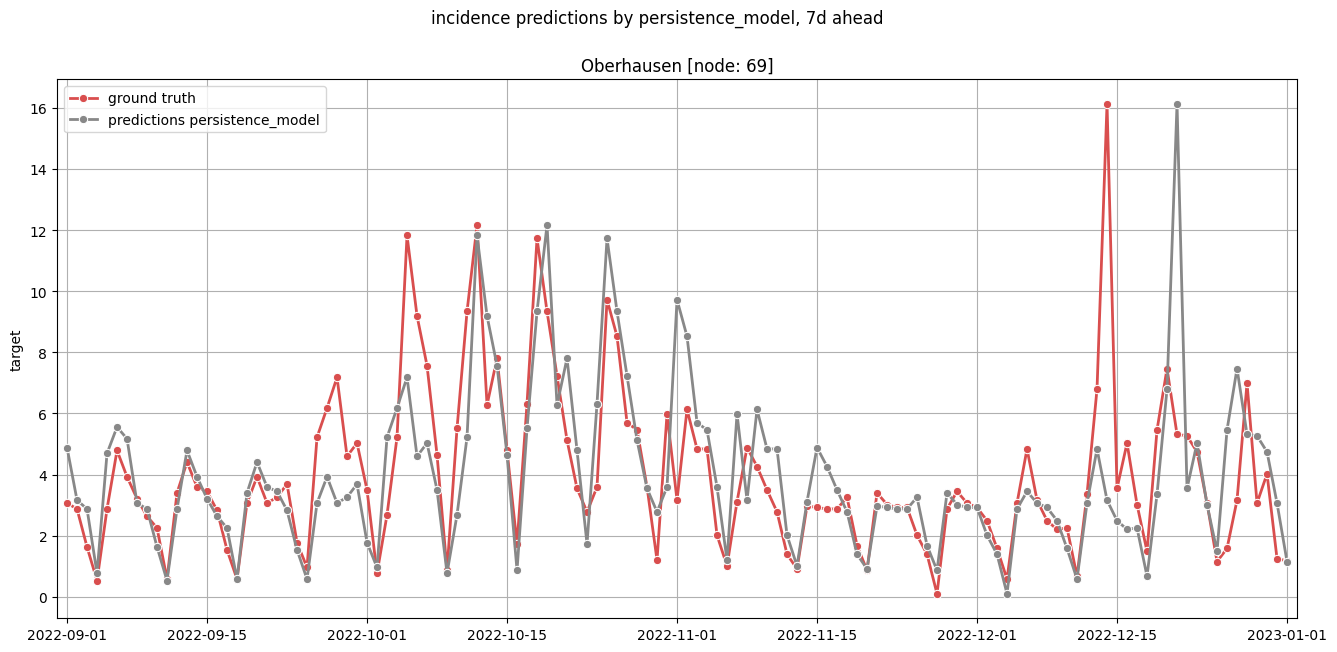

In [ ]:
from src.models import PersistenceModel 
from src.models.deep.architectures.lstm import LSTMModel
from src.models.deep.architectures.gatv2lstm import GATv2LSTMModel
from src.models.deep.architectures.tgcn import TGCNModel

from src.models.deep.architectures.gcn import SimpleGCNModel

ps = PersistenceModel(bldata)
ps.forecast('test')
ps.show_forecasts(69).show()


==                      id                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.5693, val loss: 0.7073 ✓ (new best)
Epoch 002 train loss: 0.4030, val loss: 0.4052 ✓ (new best)
Epoch 003 train loss: 0.2712, val loss: 0.3544 ✓ (new best)
Epoch 004 train loss: 0.2388, val loss: 0.3461 ✓ (new best)
Epoch 005 train loss: 0.2239, val loss: 0.3464 (patience: 1/15)
Epoch 006 train loss: 0.2136, val loss: 0.3436 ✓ (new best)
Epoch 007 train loss: 0.2065, val loss: 0.3437 (patience: 1/15)
Epoch 008 train loss: 0.2015, val loss: 0.3435 (patience: 2/15)
Epoch 009 train loss: 0.1974, val loss: 0.3440 (patience: 3/15)
Epoch 010 train loss: 0.1937, val loss: 0.3440 (patience: 4/15)
Epoch 011 train loss: 0.1908, val loss: 0.3438 (patience: 5/15)
Epoch 012 train loss: 0.1894, val loss: 0.3434 (patience: 6/15)
Epoch 013 train loss: 0.1863, val loss: 0.3433 (patience: 7/

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deepv2/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.2925
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 592.95it/s]


Test loss: 0.2804
forecasted ✓

==                     gm2                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.5437, val loss: 0.5211 ✓ (new best)
Epoch 002 train loss: 0.2687, val loss: 0.3868 ✓ (new best)
Epoch 003 train loss: 0.2231, val loss: 0.3920 (patience: 1/15)
Epoch 004 train loss: 0.2134, val loss: 0.3942 (patience: 2/15)
Epoch 005 train loss: 0.2079, val loss: 0.3957 (patience: 3/15)
Epoch 006 train loss: 0.2034, val loss: 0.3947 (patience: 4/15)
Epoch 007 train loss: 0.1997, val loss: 0.3944 (patience: 5/15)
Epoch 008 train loss: 0.1975, val loss: 0.3944 (patience: 6/15)
Epoch 009 train loss: 0.1945, val loss: 0.3932 (patience: 7/15)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 010 train loss: 0.2013, val loss: 0.3713 ✓ (new best)
Epoch 011 train loss: 0.1964, val loss: 0.3713 (patience: 1/15)
Epoch 012 train loss: 0.1950, val los

...

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deepv2/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 100 train loss: 0.1703, val loss: 0.3630 (patience: 4/15)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 570.78it/s]

Test loss: 0.3140
forecasted ✓


SimpleGCNModel(name='gm4')

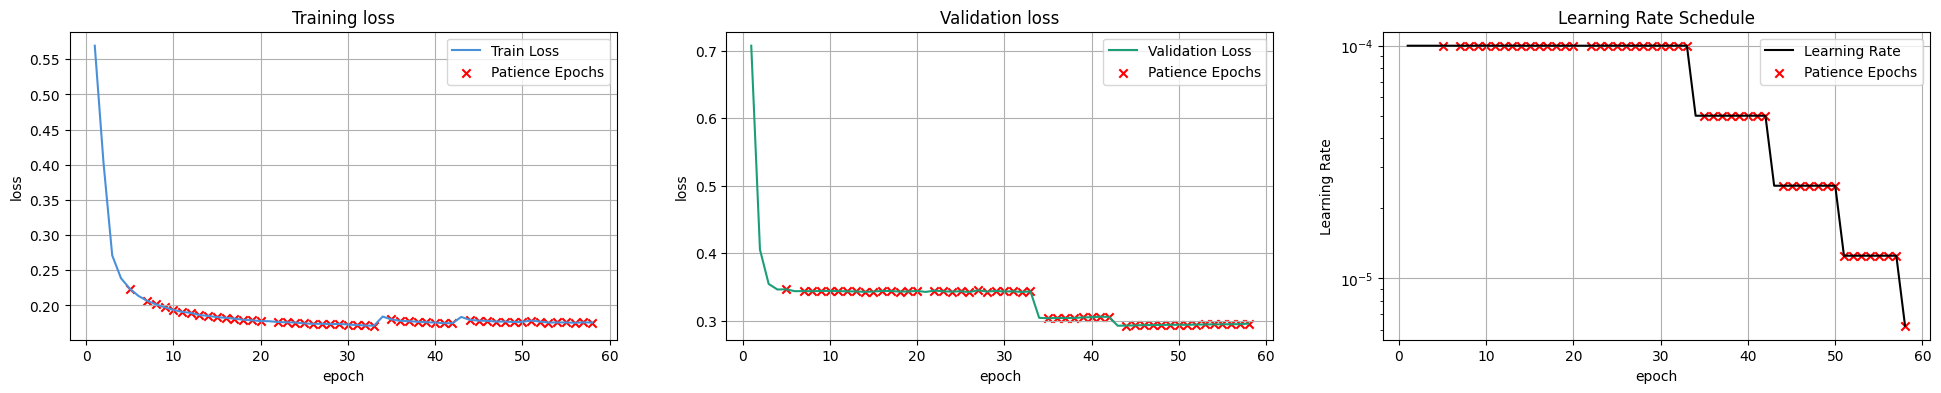

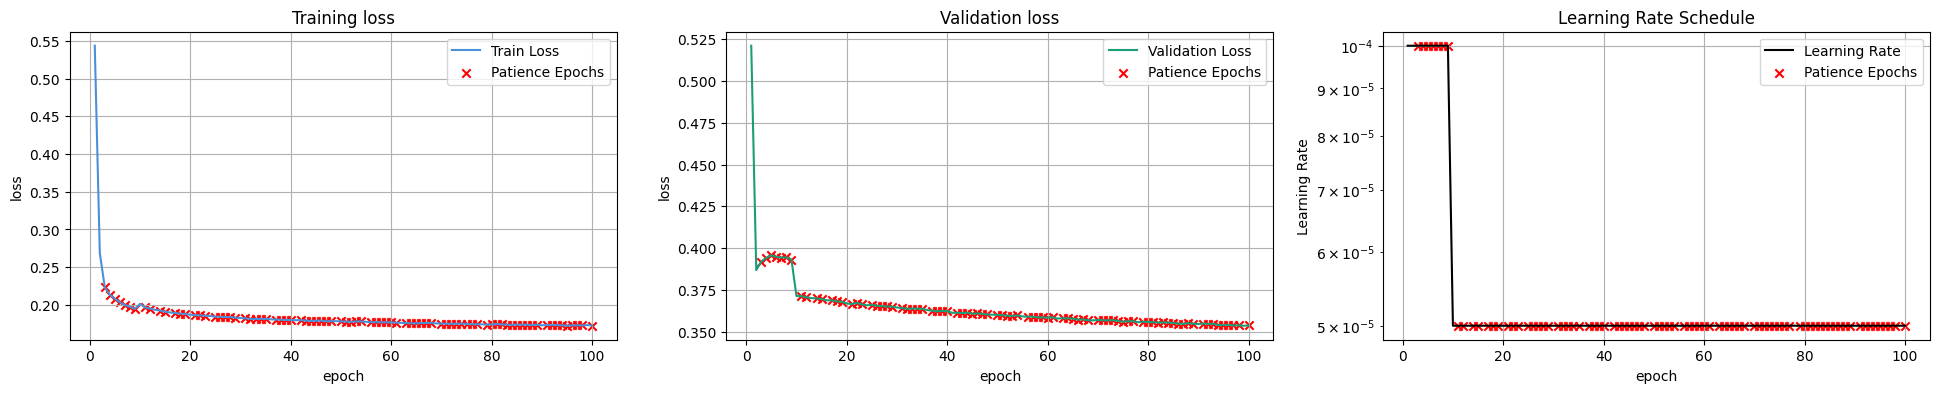

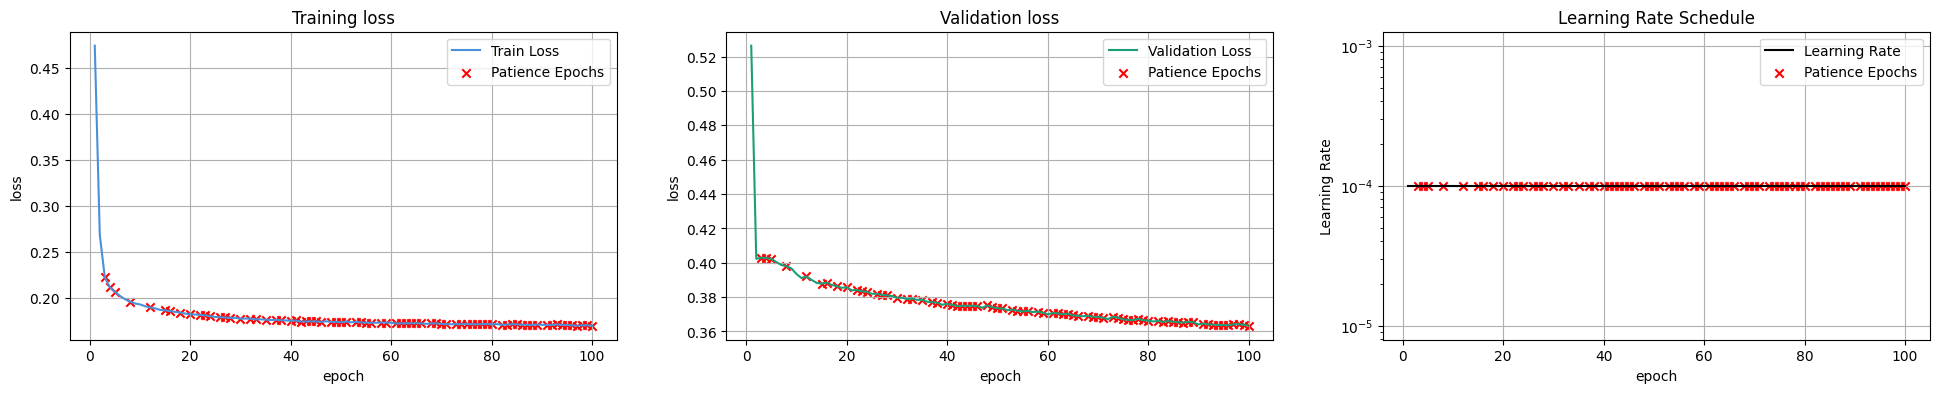

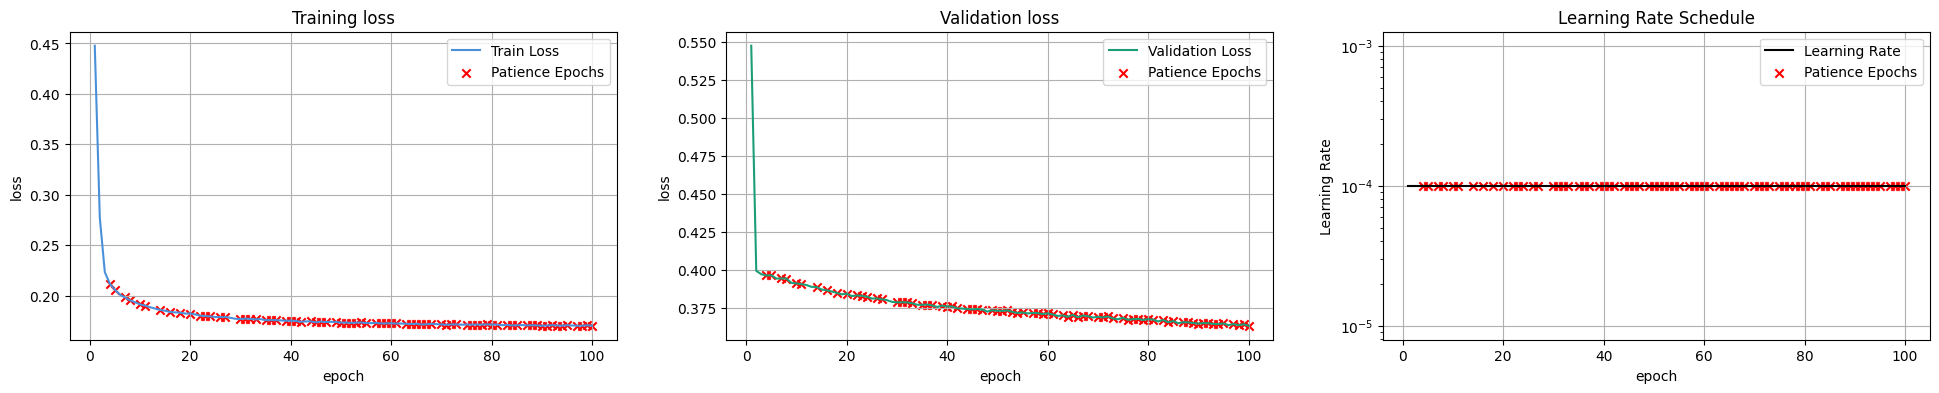

In [15]:
global_hparams = {
    'lr'    :   1e-4,
    'min_delta' : 0.001,
    'n_epochs': 100,
    'patience':15,
    'scheduler':'plateau',
    'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 6},
    }



# model_hparams = {
#     'hidden_size': 128,        # Much larger LSTM
#     'gat_hidden_dim': 32,      # Smaller GAT (less influence)
#     'num_layers': 2,
#     'num_heads': 2,            # Keep same
#     'dropout': 0.3,            # Moderate dropout
#     'temporal_layers': 2,      # If you have this parameter
# }


ml1 = SimpleGCNModel(glm, name = 'id', verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast('test')

ml2 = SimpleGCNModel(glm2, name = 'gm2', verbose = 2)
ml2.set_model_hparams()
# ml1.debug()
ml2.set_global_hparams(**global_hparams)
ml2.train()
ml2.forecast('test')

ml3 = SimpleGCNModel(glm3, name = 'gm3', verbose = 2)
ml3.set_model_hparams()
# ml1.debug()
ml3.set_global_hparams(**global_hparams)
ml3.train()
ml3.forecast('test')

ml4 = SimpleGCNModel(glm4, name = 'gm4', verbose = 2)
ml4.set_model_hparams()
# ml1.debug()
ml4.set_global_hparams(**global_hparams)
ml4.train()
ml4.forecast('test')




computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.36it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

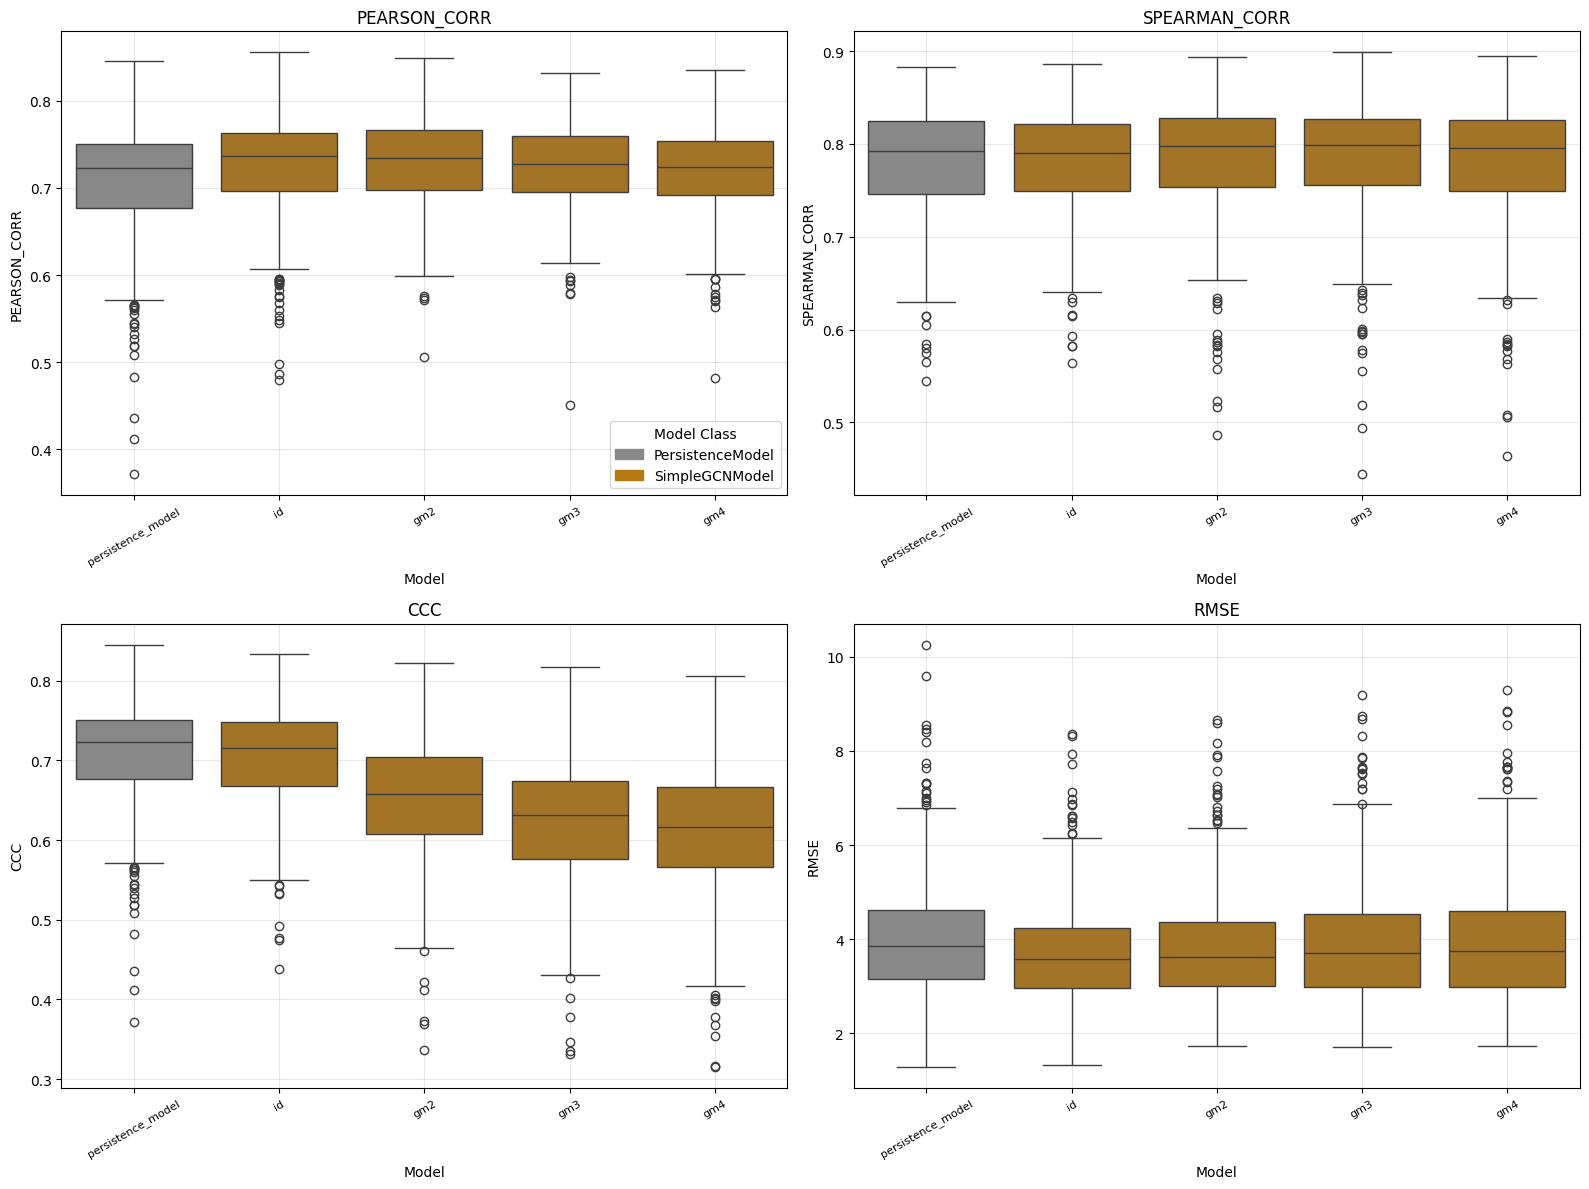

In [17]:
from src.evaluation import Evaluator 

e = Evaluator([ps, ml1, ml2, ml3, ml4]).add_evaluation()
e.plotter.plot_metric_compilation().show()

In [ ]:
graph_structure = glm2.graph
gdf = shp

# Create simulators
wave_sim = WavePropagationSimulator(gdf, graph_structure, nuts_column='nuts3_key')
standing_sim = StandingWaveSimulator(gdf, graph_structure, nuts_column='nuts3_key')
conditional_sim = ConditionalSpreadSimulator(gdf, graph_structure, nuts_column='nuts3_key')

# Generate data
years_train = [2018, 2019, 2020]
years_val = [2021]
years_test = [2022]

df_wave = wave_sim.simulate_multi_year(
    years_train, years_val, years_test,
    num_waves=4, wave_speed=1.2
)

df_standing = standing_sim.simulate_multi_year(
    years_train, years_val, years_test,
    direction='north_south', period=26
)



/local/job_24239073/ipykernel_2478605/993910357.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.geometry.centroid.x,
/local/job_24239073/ipykernel_2478605/993910357.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.geometry.centroid.y


In [91]:
import os
conditional_sim = ConditionalSpreadSimulator(gdf, graph_structure, nuts_column='nuts3_key')
df_conditional = conditional_sim.simulate_multi_year(
    years_train, years_val, years_test,
    threshold=60, num_seeds=3
)

saving = df_conditional

df_sim = saving.rename(columns = {'nuts3_key':'kz_kreis'})
path = os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/diseaseX3.csv')
df_sim.to_csv(path, index=False)

/local/job_24239073/ipykernel_2478605/858345865.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.geometry.centroid.x,
/local/job_24239073/ipykernel_2478605/858345865.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.geometry.centroid.y


computing metrics:   0%|                                                                                                                                                                | 0/8 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:03<00:00,  2.31it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

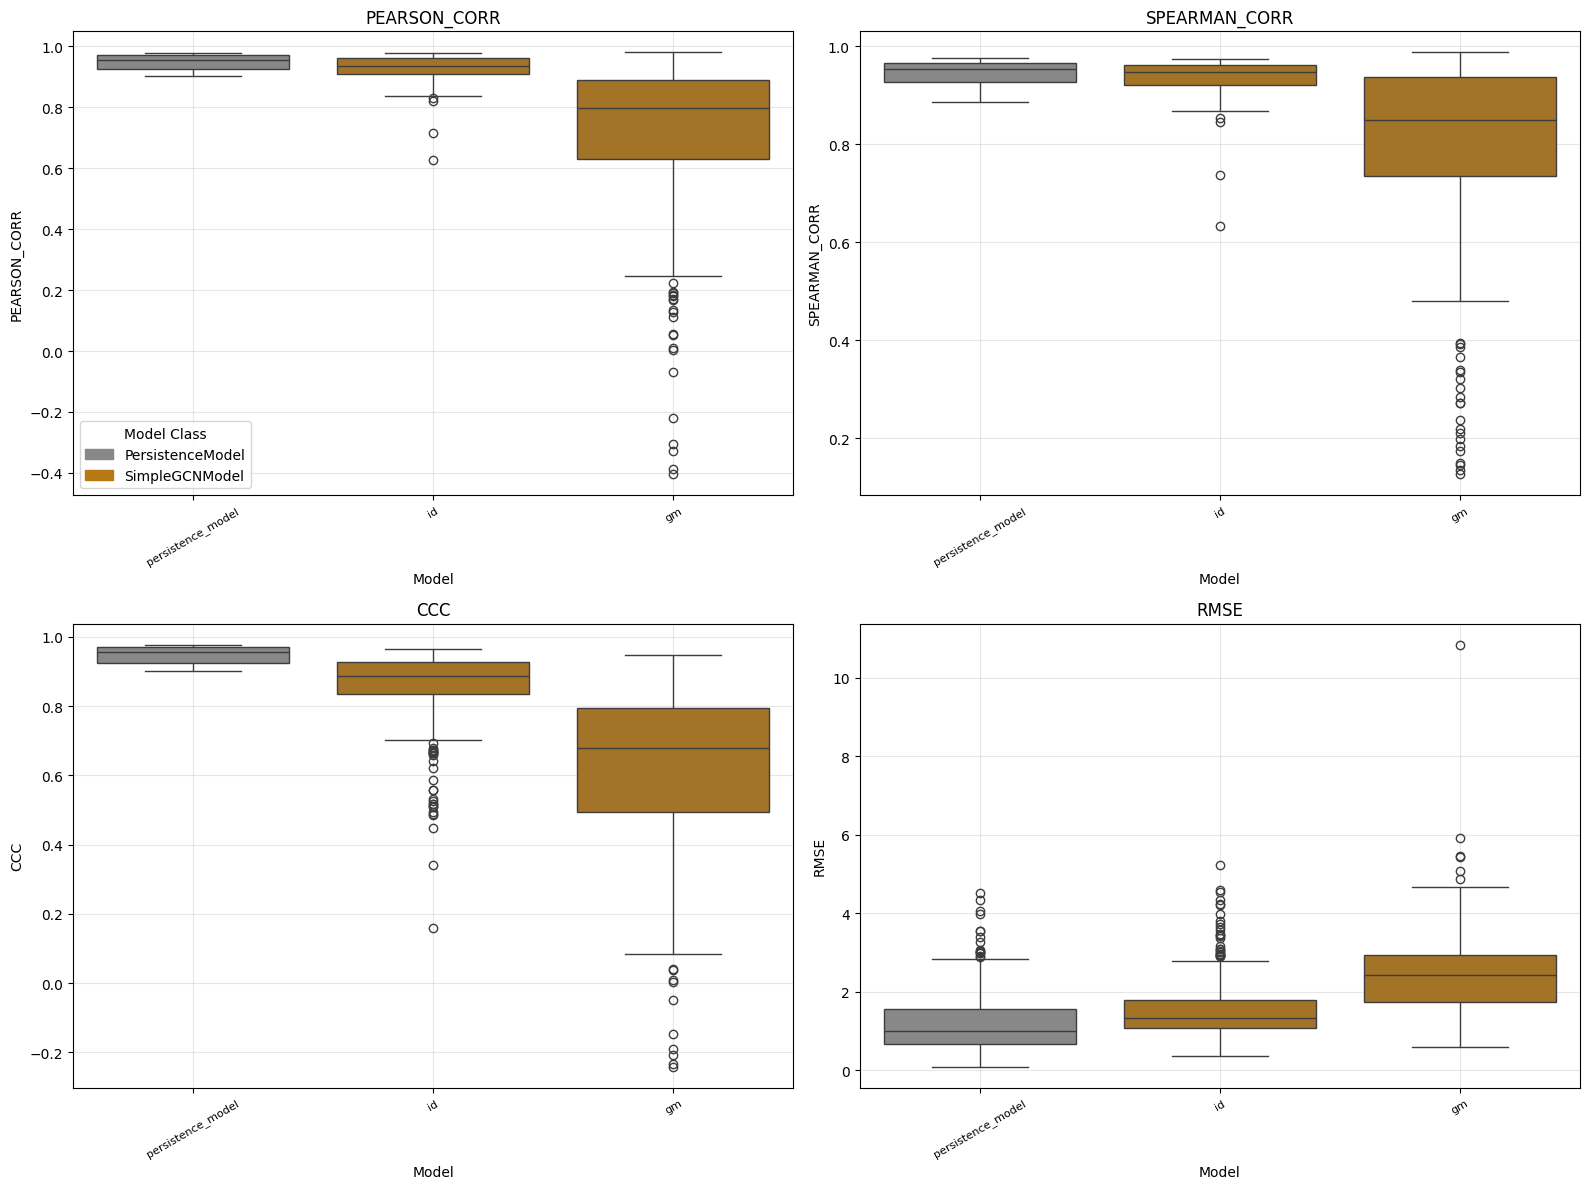